### Data processing

In [1]:
from autogluon.tabular import TabularDataset, TabularPredictor
from autogluon.features.generators import AutoMLPipelineFeatureGenerator

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import random
import pickle
import glob
from datetime import datetime
import time

import shap
from tqdm.notebook import tqdm
from scipy.interpolate import interp1d
import warnings

In [3]:
import data_processor as dp
from PIWON import HybridModel 

In [4]:
random.seed(0)
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cm=2.54

In [5]:
device

device(type='cuda')

In [6]:
data = dp.raw_data(r'data/NSQD_data.csv')
data


,EPA_Rain_Zone,Principal_Landuses,Secondary_land_use,Percentage_Residential,Percentage_Institutional,Percentage_Commercial,Percentage_Industrial,Percentage_Open_Space,Percentage_Freeway,Percentage_Water,Percentage_Unkown,Percent_Impervious,Main_Type_Conveyance,ADD,Season,TSS_mgL,Runoff_mm,Precipitation_Depth_mm,Drainage_Area_ha
0,3,ID,NaN,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,GS,9.648278,SU,370.0,6.374088,16.813495,7.891370
1,3,ID,NaN,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,GS,9.648278,WI,61.0,6.374088,16.813495,7.891370
2,3,ID,NaN,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,GS,9.648278,SP,70.0,6.374088,16.813495,7.891370
3,3,ID,NaN,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,GS,9.648278,FA,350.0,6.374088,16.813495,7.891370
4,3,ID,NaN,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,GS,9.648278,FA,129.0,6.374088,16.813495,7.891370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9046,1,CO_MIX,RE,0.31,0.0,0.56,0.13,0.0,0.0,0.0,0.0,0.81000,NaN,9.648278,SU,130.0,6.374088,16.813495,18.170385
9047,1,CO_MIX,RE,0.31,0.0,0.56,0.13,0.0,0.0,0.0,0.0,0.81000,NaN,9.648278,FA,80.0,6.374088,16.813495,18.170385
9048,1,CO_MIX,RE,0.31,0.0,0.56,0.13,0.0,0.0,0.0,0.0,0.81000,NaN,9.648278,FA,80.0,6.374088,16.813495,18.170385
9049,1,CO_MIX,RE,0.31,0.0,0.56,0.13,0.0,0.0,0.0,0.0,0.81000,NaN,9.648278,FA,280.0,6.374088,16.813495,18.170385


In [7]:
converted_data, obj_dict = dp.data_transform(data)
converted_data

('float', [])  : 14 | ['Percentage_Residential', 'Percentage_Institutional', 'Percentage_Commercial', 'Percentage_Industrial', 'Percentage_Open_Space', ...]
('object', []) :  5 | ['EPA_Rain_Zone', 'Principal_Landuses', 'Secondary_land_use', 'Main_Type_Conveyance', 'Season']


,Percentage_Residential,Percentage_Institutional,Percentage_Commercial,Percentage_Industrial,Percentage_Open_Space,Percentage_Freeway,Percentage_Water,Percentage_Unkown,Percent_Impervious,ADD,TSS_mgL,Runoff_mm,Precipitation_Depth_mm,Drainage_Area_ha,EPA_Rain_Zone,Principal_Landuses,Secondary_land_use,Main_Type_Conveyance,Season
0,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,2.365398,5.916202,1.997972,16.813495,2.185081,2,4,0,4,2
1,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,2.365398,4.127134,1.997972,16.813495,2.185081,2,4,0,4,3
2,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,2.365398,4.262680,1.997972,16.813495,2.185081,2,4,0,4,1
3,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,2.365398,5.860786,1.997972,16.813495,2.185081,2,4,0,4,0
4,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,2.365398,4.867534,1.997972,16.813495,2.185081,2,4,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9046,0.31,0.0,0.56,0.13,0.0,0.0,0.0,0.0,0.81000,2.365398,4.875197,1.997972,16.813495,2.953367,0,1,6,0,2
9047,0.31,0.0,0.56,0.13,0.0,0.0,0.0,0.0,0.81000,2.365398,4.394449,1.997972,16.813495,2.953367,0,1,6,0,0
9048,0.31,0.0,0.56,0.13,0.0,0.0,0.0,0.0,0.81000,2.365398,4.394449,1.997972,16.813495,2.953367,0,1,6,0,0
9049,0.31,0.0,0.56,0.13,0.0,0.0,0.0,0.0,0.81000,2.365398,5.638355,1.997972,16.813495,2.953367,0,1,6,0,0


In [8]:
re_data = dp.data_retransform(converted_data,obj_dict)
re_data

c:\Users\pc\nps\github\data_processor.py:141: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(obj_dict[col])


,Percentage_Residential,Percentage_Institutional,Percentage_Commercial,Percentage_Industrial,Percentage_Open_Space,Percentage_Freeway,Percentage_Water,Percentage_Unkown,Percent_Impervious,ADD,TSS_mgL,Runoff_mm,Precipitation_Depth_mm,Drainage_Area_ha,EPA_Rain_Zone,Principal_Landuses,Secondary_land_use,Main_Type_Conveyance,Season
0,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,9.648278,370.0,6.374088,16.813495,7.891370,3,ID,NaN,GS,SU
1,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,9.648278,61.0,6.374088,16.813495,7.891370,3,ID,NaN,GS,WI
2,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,9.648278,70.0,6.374088,16.813495,7.891370,3,ID,NaN,GS,SP
3,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,9.648278,350.0,6.374088,16.813495,7.891370,3,ID,NaN,GS,FA
4,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,9.648278,129.0,6.374088,16.813495,7.891370,3,ID,NaN,GS,FA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9046,0.31,0.0,0.56,0.13,0.0,0.0,0.0,0.0,0.81000,9.648278,130.0,6.374088,16.813495,18.170385,1,CO_MIX,RE,NaN,SU
9047,0.31,0.0,0.56,0.13,0.0,0.0,0.0,0.0,0.81000,9.648278,80.0,6.374088,16.813495,18.170385,1,CO_MIX,RE,NaN,FA
9048,0.31,0.0,0.56,0.13,0.0,0.0,0.0,0.0,0.81000,9.648278,80.0,6.374088,16.813495,18.170385,1,CO_MIX,RE,NaN,FA
9049,0.31,0.0,0.56,0.13,0.0,0.0,0.0,0.0,0.81000,9.648278,280.0,6.374088,16.813495,18.170385,1,CO_MIX,RE,NaN,FA


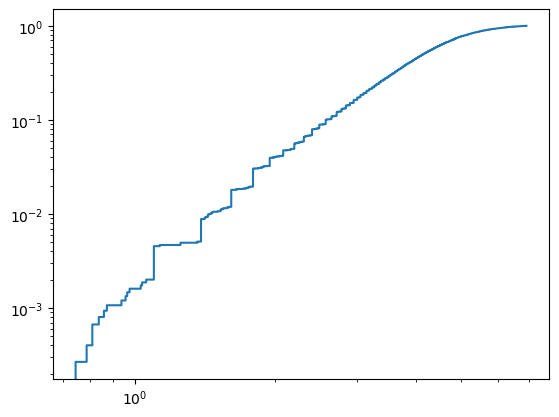

In [9]:
def ecdf4plot(seq, assumeSorted = False):
    """
    In:
    seq - sorted-able object containing values
    assumeSorted - specifies whether seq is sorted or not
    Out:
    0. values of support at both points of jump discontinuities
    1. values of ECDF at both points of jump discontinuities
       ECDF's true value at a jump discontinuity is the higher one    """
    if not assumeSorted:
        seq = sorted(seq)
    prev = seq[0]
    n = len(seq)
    support = [prev]
    ECDF = [0.]
    for i in range(1, n):
        seqi = seq[i]
        if seqi != prev:
            preP = i/n
            support.append(prev)
            ECDF.append(preP)
            support.append(seqi)
            ECDF.append(preP)
            prev = seqi
    support.append(prev)
    ECDF.append(1.)
    return support, ECDF

# example usage
import numpy as np
from matplotlib import pyplot as plt

plt.plot(*ecdf4plot(converted_data['TSS_mgL']))
plt.xscale('log')
plt.yscale('log')

Text(0, 0.5, 'Count')

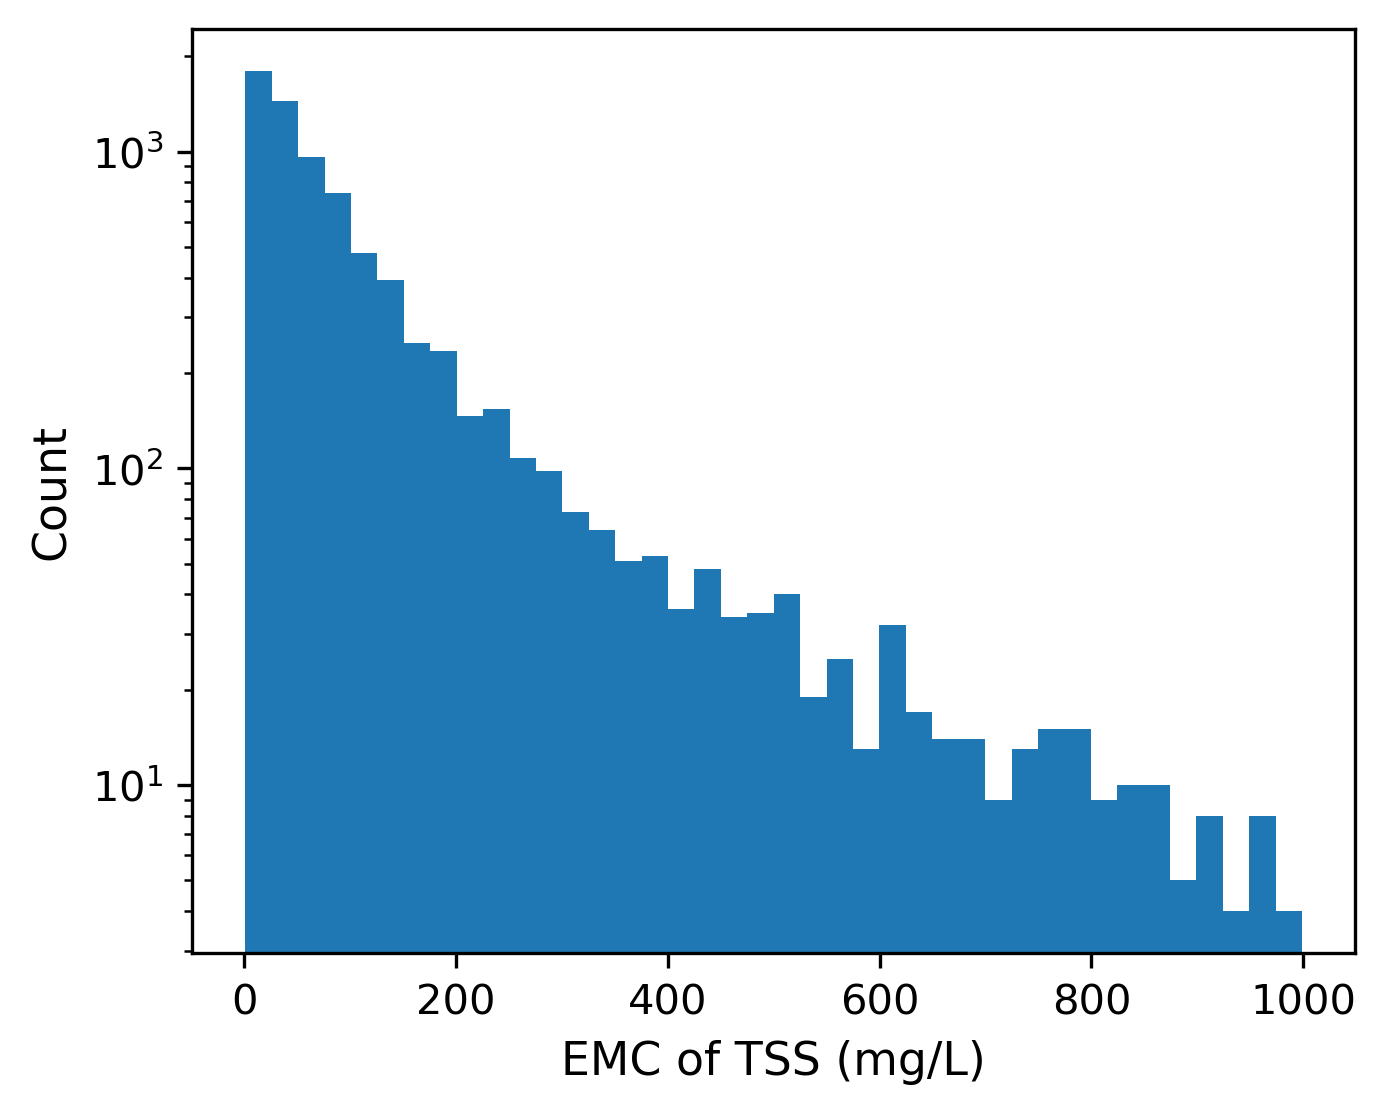

In [10]:
plt.figure(figsize = [5,4], dpi = 300)
plt.hist((np.expm1(converted_data['TSS_mgL'])), bins = 40)
plt.yscale('log')
plt.xlabel('EMC of TSS (mg/L)', fontsize = 11)
plt.ylabel('Count',fontsize = 11)

In [11]:
# Split data for train (90%) and test (10%), with random state = 0 for reproduction
_train_set, test_set = train_test_split(converted_data, test_size = 0.1, random_state = 0)

In [12]:
# Generate rainfall time series for each event, by
# 1) chicago design storm equations, or
# 2) distributing rainfall volume into 120 mins uniformly.

def chicago_storm(c):
  A = 14.004
  t = 120
  b = 11.305
  n = 0.557
  r = 0.35
  rain = []
  for i in range(41, -1, -1):
    x = A * ((1 - n) * i / r + b)
    y = (i / r + b) ** (n + 1)
    rain.append(x/y)

  for i in range(1,79):
    x = A * ((1 - n) * i / (1 - r) + b) / ((i / (1 - r) + b) ** (n + 1))
    rain.append(x)

  return np.array(rain) * c / sum(rain)


def rainfall_generator(data, chicago = True):
  if chicago:
    a = []
    basic = chicago_storm(1)
    for _, row in data.iterrows():
      rain = (row['Precipitation_Depth_mm'] * basic).reshape((120,1))
      # convert precipitation after rain generation
      row['Precipitation_Depth_mm'] = 5 * np.arctan(row['Precipitation_Depth_mm']/20)
      other = np.repeat([row.values], 120, axis = 0)
      ts = np.concatenate((rain, other), axis=1)
      a.append(ts)
    return torch.tensor(np.array(a))
  else:
    return torch.tensor([np.repeat([np.insert(row.values, 0, row['Precipitation_Depth_mm']/120)], 120, axis=0) for _, row in data.iterrows()], dtype=torch.float, device = device)

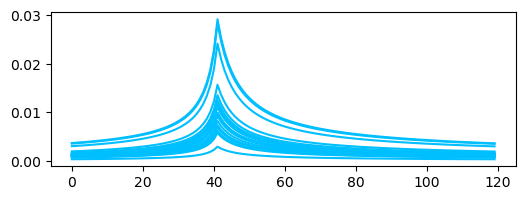

In [13]:
plt.figure(figsize=[6,2])
for i in np.random.rand(20):
  plt.plot(chicago_storm(i),c='deepskyblue')


In [14]:

# Convert dataframe to dataloader of torch
def data_loader(data, batch_size,shuffle=False,):
  label = torch.tensor(data[['TSS_mgL', 'Runoff_mm']].values, dtype=torch.float, device = device).to(torch.float32)
  x = rainfall_generator(data.drop('TSS_mgL', axis = 1), chicago = True).to(torch.float32)
  dataset = TensorDataset(x, label)
  data_loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=shuffle, drop_last = False)
  return data_loader

In [15]:
train_loader = data_loader(_train_set, batch_size = 4)

In [16]:
test_data, test_label = next(iter(train_loader))
test_data.to(device)
test_label.to(device)
test_data.shape

torch.Size([4, 120, 19])

In [17]:
for i, data in enumerate(train_loader):
  print(i, data[0].shape, data[1].shape)
  break

0 torch.Size([4, 120, 19]) torch.Size([4, 2])


### Training function

In [22]:
# helper function to print time elapsed and estimated time remaining
import time
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from copy import deepcopy

def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)


def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))


def showPlot(points):
    fig, ax = plt.subplots()
    # this locator puts ticks at regular intervals
    # loc = ticker.MultipleLocator(base=0.2)
    # ax.yaxis.set_major_locator(loc)
    plt.plot(points)

def xavier_init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)
    if type(m) == nn.GRU:
        for param in m._flat_weights_names:
            if "weight" in param:
                nn.init.xavier_uniform_(m._parameters[param])



def r2_loss(y_pred, y_true):
    ss_res = torch.sum(torch.square(y_true - y_pred))
    ss_tot = torch.sum(torch.square(y_true - torch.mean(y_true)))
    r2 = 1 - (ss_res / ss_tot)
    # Return negative R2 score as loss
    return -r2

def smoothness_penalty(pred):
    # Compute the second derivative of the predicted load curve
    dpred = pred[:, 1:] - pred[:, :-1]
    d2pred = dpred[:, 1:] - dpred[:, :-1]

    # Compute the L2 norm of the second derivative
    return torch.mean(torch.square(d2pred))



def exponential_penalty(pred):
    n = pred.shape[1]
    x = torch.arange(n, dtype=torch.float32, device=pred.device)
    A = pred[:, 0].reshape(-1, 1)
    value_range = (pred[:, -1] - pred[:, 0]).reshape(-1, 1)
    k = -torch.log(torch.tensor(1 - 0.6, device=pred.device)) / (0.4 * n)
    trend = A + value_range * (1 - torch.exp(-k * x))
    penalty = torch.mean((pred - trend)**2)
    return penalty


In [23]:
def train(net, train_set, valid_set, test_set, batch_size, num_epochs,  print_every = 50, continue_train = False):

    train_losses = []
    net.to(device)

    if not continue_train:
      net.apply(xavier_init_weights)
      lr = 1e-3
    else:
      lr = 1e-4


    optimizer = torch.optim.Adam(net.parameters(), lr = lr)
    loss = nn.MSELoss()
    # loss = r2_loss


    start = time.time()
    print_loss_total = 0  # Reset every print_every
    plot_loss_total = 0  # Reset every plot_every

    test_loader = data_loader(test_set, batch_size = test_set.shape[0])
    test_losses = []

    valid_loader = data_loader(valid_set, batch_size = valid_set.shape[0])
    valid_losses = []

    best_valid_loss = float('inf')
    patience = 50

    gradient_flat = 0
    for epoch in range(1, num_epochs + 1):
        net.train()

        train_loader = data_loader(train_set, batch_size = batch_size)
        epoch_loss = 0
        for i, batch in enumerate(train_loader):

            batch_loss = 0

            optimizer.zero_grad()
            data, label = [x.to(device) for x in batch]

            _, total_runoff, load_record = net(data)
            if (total_runoff == 0).all():
              print('bad news')
              gradient_flat = 1

            total_runoff = torch.where(total_runoff == 0, torch.finfo().tiny, total_runoff)

            if load_record.isnan().any():
              print('nan load_record')
              gradient_flat = 1

            if ((load_record[:,0] - load_record[:,-1])/torch.flatten(total_runoff)).isnan().any():
              print('nan estimate TSS')
              gradient_flat = 1
            
            if gradient_flat == 1:
              try:
                 net.load_state_dict(best_model_state)
                 gradient_flat = 0
                 continue
              except:
                 print('failed seed')
                 return train_losses, valid_losses,test_losses, False


            l = 1e-4 * exponential_penalty(load_record) + loss((load_record[:,0] - load_record[:,-1])/torch.flatten(total_runoff), label[:,0])


            epoch_loss += l.item()


            
            # l = 0.9 * l + 0.1 * l_TSS
            l.backward()
            optimizer.step()

            #print('this is batch',i,'for epoch',epoch)
            #print('l_runoff = ',l_runoff, 'l_TSS = ',l_TSS )

        print_loss_total += epoch_loss/(len(train_loader))
        #print(TSS_losses)
        #######################################################
        net.eval()
        data, label = [x.to(device) for x in next(iter(valid_loader))]
        _, total_runoff, load_record = net(data)
        total_runoff = torch.where(total_runoff == 0, torch.finfo().tiny, total_runoff)
        l_valid = 1e-4 * exponential_penalty(load_record) + loss((load_record[:,0] - load_record[:,-1])/torch.flatten(total_runoff), label[:,0]).cpu()
        #######################################################
        #######################################################
        data, label = [x.to(device) for x in next(iter(test_loader))]
        _, total_runoff, load_record = net(data)
        total_runoff = torch.where(total_runoff == 0, torch.finfo().tiny, total_runoff)
        l_test = 1e-4 * exponential_penalty(load_record) + loss((load_record[:,0] - load_record[:,-1])/torch.flatten(total_runoff), label[:,0]).cpu()
        net.train()
        #######################################################

        test_losses.append(l_test.item())
        valid_losses.append(l_valid.item())
        train_losses.append(epoch_loss/len(train_loader))

        if l_valid < best_valid_loss:
            best_valid_loss = l_valid
            best_model_state = deepcopy(net.state_dict())
            bad_epochs = 0
        else:

            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Validation loss has not improved for {patience} epochs. "
                      f"Training paused. Press 'c' and Enter to continue training, or 'q' to quit.")
                while True:

                    user_input = 'c' # input()
                    if user_input.lower() == 'c':
                        bad_epochs = 0
                        break
                    elif user_input.lower() == 'q':
                        return train_losses, valid_losses, test_losses, best_model_state
                    else:
                        print


        if epoch % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%)' % (timeSince(start, epoch / num_epochs),
                                        epoch, epoch / num_epochs * 100))
            print('train loss: %.4f' % print_loss_avg)
            print('valid loss: %.4f' % l_valid.item())
            print('test loss: %.4f' % l_test.item())
            print('')


    plt.plot(train_losses, label = 'Train loss')
    plt.plot(valid_losses, label = 'Valid loss')
    plt.plot(test_losses, label = 'Test loss')
    plt.legend()
    plt.yscale('log')
    plt.show()
    return train_losses, valid_losses,test_losses, best_model_state

### Training

In [19]:
with open('checkpoint/v1',  'rb') as f:
  v1 = pickle.load(f)

In [20]:
hidden_size = 256
input_size = 18
dropout = 0.1

net = HybridModel(input_size, hidden_size, n_layers = 2, dropout = 0)
net.load_state_dict(v1[0])

<All keys matched successfully>

0m 53s (- 69m 52s) (5 1%)
train loss: 5.5916
valid loss: 4.4321
test loss: 4.1716

1m 43s (- 66m 57s) (10 2%)
train loss: 3.5059
valid loss: 2.8071
test loss: 2.5870

2m 33s (- 65m 35s) (15 3%)
train loss: 1.4558
valid loss: 1.2256
test loss: 1.0573

3m 24s (- 64m 38s) (20 5%)
train loss: 1.0842
valid loss: 1.0688
test loss: 0.9020

4m 15s (- 63m 45s) (25 6%)
train loss: 0.9287
valid loss: 0.9001
test loss: 0.7377

5m 9s (- 63m 35s) (30 7%)
train loss: 0.7311
valid loss: 0.7075
test loss: 0.5820

6m 5s (- 63m 27s) (35 8%)
train loss: 0.5934
valid loss: 0.6335
test loss: 0.5230

7m 0s (- 63m 2s) (40 10%)
train loss: 0.5466
valid loss: 0.5862
test loss: 0.4851

7m 58s (- 62m 52s) (45 11%)
train loss: 0.5290
valid loss: 0.5892
test loss: 0.5007

8m 53s (- 62m 17s) (50 12%)
train loss: 0.5105
valid loss: 0.6160
test loss: 0.5258

9m 49s (- 61m 37s) (55 13%)
train loss: 0.4978
valid loss: 0.5611
test loss: 0.4802

10m 50s (- 61m 26s) (60 15%)
train loss: 0.4915
valid loss: 0.5377
test loss:

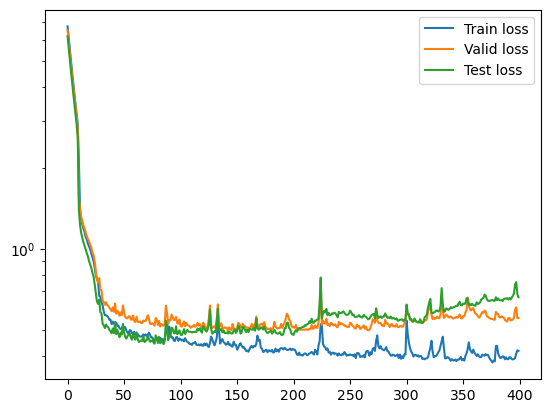

0m 55s (- 72m 38s) (5 1%)
train loss: 5.6046
valid loss: 4.4304
test loss: 4.1843

1m 51s (- 72m 42s) (10 2%)
train loss: 3.5269
valid loss: 2.8399
test loss: 2.6442

2m 47s (- 71m 46s) (15 3%)
train loss: 1.5329
valid loss: 1.1962
test loss: 1.0617

3m 43s (- 70m 43s) (20 5%)
train loss: 1.0794
valid loss: 1.0488
test loss: 0.9125

4m 40s (- 70m 13s) (25 6%)
train loss: 0.9688
valid loss: 0.9522
test loss: 0.7940

5m 37s (- 69m 25s) (30 7%)
train loss: 0.8162
valid loss: 0.7305
test loss: 0.6180

6m 33s (- 68m 27s) (35 8%)
train loss: 0.6997
valid loss: 0.8647
test loss: 0.7799

7m 23s (- 66m 30s) (40 10%)
train loss: 0.6007
valid loss: 0.6969
test loss: 0.6308

8m 13s (- 64m 50s) (45 11%)
train loss: 0.5548
valid loss: 0.5716
test loss: 0.5137

9m 2s (- 63m 14s) (50 12%)
train loss: 0.5225
valid loss: 0.5386
test loss: 0.4857

9m 51s (- 61m 50s) (55 13%)
train loss: 0.5047
valid loss: 0.5245
test loss: 0.4730

10m 41s (- 60m 34s) (60 15%)
train loss: 0.4946
valid loss: 0.5345
test lo

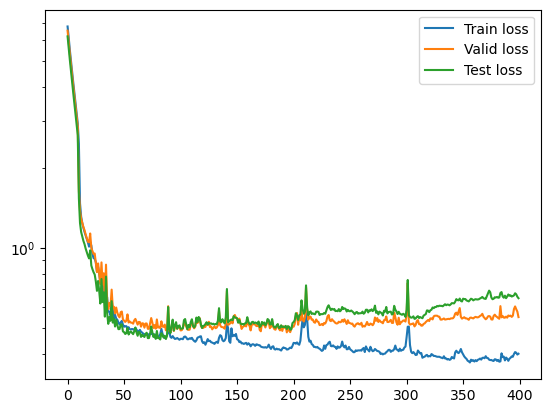

0m 48s (- 64m 1s) (5 1%)
train loss: 5.6009
valid loss: 4.4674
test loss: 4.1805

1m 39s (- 64m 53s) (10 2%)
train loss: 3.3067
valid loss: 1.6234
test loss: 1.4331

2m 30s (- 64m 11s) (15 3%)
train loss: 1.3459
valid loss: 1.2996
test loss: 1.1082

3m 20s (- 63m 31s) (20 5%)
train loss: 1.1231
valid loss: 1.1103
test loss: 0.9355

4m 9s (- 62m 21s) (25 6%)
train loss: 0.9485
valid loss: 0.9359
test loss: 0.7699

4m 58s (- 61m 20s) (30 7%)
train loss: 0.7814
valid loss: 0.7125
test loss: 0.5653

5m 47s (- 60m 22s) (35 8%)
train loss: 0.6193
valid loss: 0.6560
test loss: 0.5228

6m 36s (- 59m 25s) (40 10%)
train loss: 0.5529
valid loss: 0.6316
test loss: 0.5080

7m 26s (- 58m 40s) (45 11%)
train loss: 0.5305
valid loss: 0.6110
test loss: 0.4937

8m 15s (- 57m 46s) (50 12%)
train loss: 0.5228
valid loss: 0.5927
test loss: 0.4787

9m 4s (- 56m 57s) (55 13%)
train loss: 0.5034
valid loss: 0.5729
test loss: 0.4604

9m 53s (- 56m 5s) (60 15%)
train loss: 0.4887
valid loss: 0.5631
test loss: 

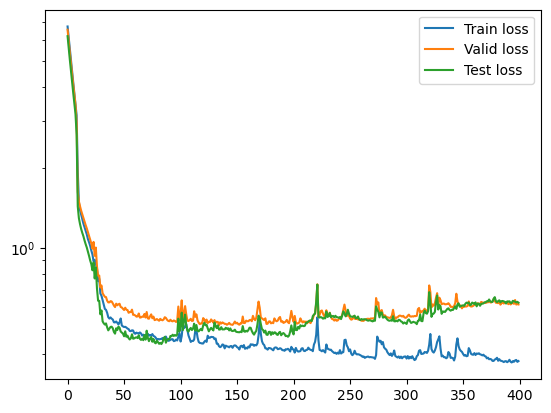

0m 47s (- 62m 19s) (5 1%)
train loss: 5.6007
valid loss: 4.3210
test loss: 4.1878

1m 36s (- 62m 48s) (10 2%)
train loss: 3.4379
valid loss: 1.6222
test loss: 1.5590

2m 25s (- 62m 10s) (15 3%)
train loss: 1.3350
valid loss: 1.2019
test loss: 1.1050

3m 14s (- 61m 36s) (20 5%)
train loss: 1.1109
valid loss: 1.0342
test loss: 0.9479

4m 3s (- 60m 48s) (25 6%)
train loss: 0.9652
valid loss: 0.7985
test loss: 0.7300

4m 52s (- 60m 6s) (30 7%)
train loss: 0.8516
valid loss: 0.6844
test loss: 0.6214

5m 41s (- 59m 20s) (35 8%)
train loss: 0.6178
valid loss: 0.5770
test loss: 0.5167

6m 29s (- 58m 26s) (40 10%)
train loss: 0.5585
valid loss: 0.5894
test loss: 0.5393

7m 19s (- 57m 45s) (45 11%)
train loss: 0.5247
valid loss: 0.5256
test loss: 0.4768

8m 7s (- 56m 53s) (50 12%)
train loss: 0.5072
valid loss: 0.5177
test loss: 0.4705

8m 56s (- 56m 5s) (55 13%)
train loss: 0.5024
valid loss: 0.5250
test loss: 0.4861

9m 46s (- 55m 21s) (60 15%)
train loss: 0.4966
valid loss: 0.5055
test loss: 

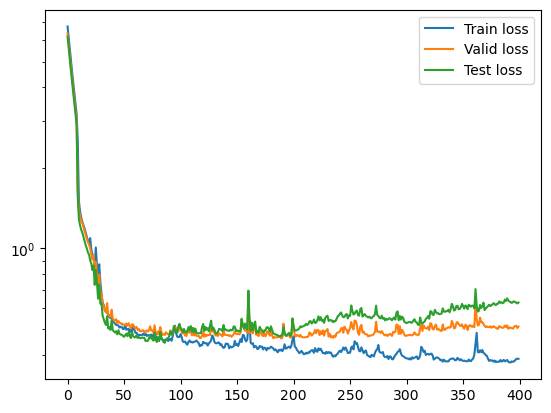

0m 48s (- 63m 52s) (5 1%)
train loss: 5.6126
valid loss: 4.2391
test loss: 4.1824

1m 38s (- 64m 6s) (10 2%)
train loss: 3.5264
valid loss: 2.7195
test loss: 2.6644

2m 28s (- 63m 19s) (15 3%)
train loss: 1.5983
valid loss: 1.1270
test loss: 1.0630

3m 18s (- 62m 45s) (20 5%)
train loss: 1.0818
valid loss: 0.9912
test loss: 0.9036

4m 7s (- 61m 59s) (25 6%)
train loss: 0.9417
valid loss: 0.8422
test loss: 0.8015

4m 57s (- 61m 8s) (30 7%)
train loss: 0.8048
valid loss: 0.7052
test loss: 0.6692

5m 47s (- 60m 20s) (35 8%)
train loss: 0.7078
valid loss: 0.6140
test loss: 0.5759

6m 36s (- 59m 30s) (40 10%)
train loss: 0.6333
valid loss: 0.5398
test loss: 0.5136

7m 26s (- 58m 45s) (45 11%)
train loss: 0.5529
valid loss: 0.5074
test loss: 0.4854

8m 16s (- 57m 54s) (50 12%)
train loss: 0.5268
valid loss: 0.5042
test loss: 0.4866

9m 5s (- 57m 3s) (55 13%)
train loss: 0.5074
valid loss: 0.4844
test loss: 0.4659

9m 55s (- 56m 12s) (60 15%)
train loss: 0.4968
valid loss: 0.4849
test loss: 0

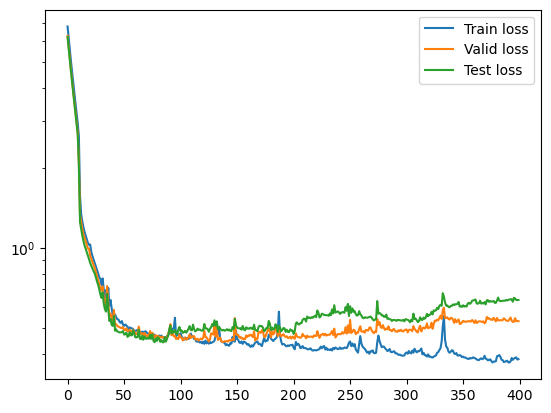

In [ ]:
for s in range(5):
    net.load_state_dict(v1[0])
    train_set, valid_set = train_test_split(_train_set, test_size = 0.1111, random_state = s)
    train_losses, valid_losses,test_losses, best_model_state = train(net, train_set, valid_set, test_set, batch_size = 256, num_epochs = 400, print_every = 5, continue_train = True)
    if best_model_state:
        time_lable = time.strftime("%b%d", time.localtime())
        with open(f'checkpoint/v2_seed_{s}_{time_lable}_71fusion_1e4.pkl', 'wb') as f:
            pickle.dump((train_losses, valid_losses,test_losses, best_model_state), f)


### MV curve

In [97]:
train_loader = data_loader(_train_set, batch_size = _train_set.shape[0])
test_loader = data_loader(test_set, batch_size = test_set.shape[0])
loader = data_loader(converted_data, batch_size = converted_data.shape[0])
loss = nn.MSELoss()

In [98]:
path=glob.glob('checkpoint/v2_*.pkl') 
path

['checkpoint\\v2_seed_0_Oct19.pkl',
 'checkpoint\\v2_seed_1_Oct19.pkl',
 'checkpoint\\v2_seed_2_Oct19.pkl',
 'checkpoint\\v2_seed_3_Oct19.pkl',
 'checkpoint\\v2_seed_4_Oct19.pkl']

In [99]:
hidden_size = 256
input_size = 18
dropout = 0.1
net = HybridModel(input_size, hidden_size, n_layers = 2, dropout = 0.1)
#model_state = load_test[-1]


for s,p in enumerate(path[3:4]):
    with open(p, 'rb') as f:
        train_losses, valid_losses,test_losses, best_model_state = pickle.load(f)
        net.load_state_dict(best_model_state)
        net.eval()
        net.to(device)
        
        data, label = [x.to(device) for x in next(iter(loader))]
        
        with torch.no_grad():
            runoff, total_runoff, load_record = net(data)

        
        from scipy.interpolate import interp1d
        import numpy as np
        from scipy import stats

        cm = 2.54
        # plt.figure(figsize = [10/cm,8/cm], dpi = 100)

        n = 1000

        mff20s = []
        mff30s = []
        ffis = []
        fs = []
        x = np.linspace(0,99.9,1000)
        y = []
        dx = 0.1 
        xx = []
        yy = []

        for i in range(runoff.shape[0]):
            a = np.cumsum(runoff[i,:,0].cpu())
            a = 100 * a/a[-1]
            a = np.insert(np.array(a.cpu()),0,0)
            xx.append(a)

            b = load_record[i,0] - load_record[i,1:]
            b = 100 * b/b[-1]
            b = np.insert(np.array(b.cpu()),0,0)
            yy.append(b)

            f = interp1d(a, b, kind='linear')
            fs.append(f)
            _y = f(x)
            y.append(_y)

            mff20s.append(f(20)/20)
            mff30s.append(f(30)/30)
             #每个矩形的宽度
            fArea = np.nansum(_y*dx)
            ffis.append(2*fArea/10000)
            # plt.plot(a,b, c = 'grey', alpha = 0.25)


        y_mean = np.mean(np.array(y),axis = 0)
        xx = np.array(xx)
        yy = np.array(yy)
        y = np.array(y)

        # plt.plot(x,y_mean,c = 'r')


        # plt.xlabel('Cumulative runoff volume (%)')
        # plt.ylabel('Cumulative pollutant mass (%)')

        # plt.plot([0,100],[0,100], c = 'black')
        # plt.grid()
        # plt.xlim([0,100])
        # plt.ylim([0,102])
        # plt.show()

        f = interp1d(x, y_mean, kind='linear')
        print('mff30', f(30)/30) 
        print('mff20', f(20)/20) 
                      #每个矩形的宽度
        fArea = np.nansum(y_mean*dx)
                    

        print('First flush index:', 2*fArea/10000)

C:\Users\pc\AppData\Local\Temp\ipykernel_7152\1239642887.py:43: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  a = np.insert(np.array(a.cpu()),0,0)
C:\Users\pc\AppData\Local\Temp\ipykernel_7152\1239642887.py:48: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  b = np.insert(np.array(b.cpu()),0,0)
c:\ProgramData\anaconda3\envs\ag\Lib\site-packages\scipy\interpolate\_interpolate.py:497: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


mff30 3.154944468980824
mff20 4.057927812153086
First flush index: 1.7737988183046844


In [100]:
load_record = load_record.cpu()
runoff = runoff.cpu().reshape(-1,240)
concentration = -(np.diff(load_record, axis = 1)/runoff)

c:\ProgramData\anaconda3\envs\ag\Lib\site-packages\torch\_tensor.py:1102: RuntimeWarning: invalid value encountered in multiply
  return self.reciprocal() * other


In [101]:
def calculate_stats(t, Q, C, capacity_mm=5.0):
    dt = t[1] - t[0]
    total_vol = np.sum(Q) * dt
    mass_load = Q * C * dt # Mass per time step
    total_mass = np.sum(mass_load)
    
    # 1. Volume-Based (First Flush)
    # Take first N steps where cumulative Q <= capacity
    cum_Q = np.cumsum(Q) * dt
    # Find index where capacity is reached
    idx_vol = np.searchsorted(cum_Q, capacity_mm)
    # Handle partial step if needed, but for viz integer steps are fine if resolution is high
    # Let's be precise: exact fraction of last step?
    # For visualization "fill", mask is easier.
    vol_mask = cum_Q <= capacity_mm
    # If the first step > capacity (unlikely for 10mm), handle it.
    if not np.any(vol_mask) and capacity_mm > 0:
         vol_mask[0] = True # Take at least part of first
    
    mass_treated_vol = np.sum(mass_load[vol_mask])
    # Correction for the transition step where it exceeds 10mm
    # Calculate exact:
    idx_exceed = np.argmax(cum_Q > capacity_mm)
    if cum_Q[idx_exceed] > capacity_mm and idx_exceed > 0:
        # volume filled before this step
        vol_prev = cum_Q[idx_exceed-1]
        vol_needed = capacity_mm - vol_prev
        # Fraction of this step taken
        frac = vol_needed / (Q[idx_exceed] * dt)
        mass_treated_vol = np.sum(mass_load[:idx_exceed]) + mass_load[idx_exceed] * frac
        # For mask plotting, we usually just highlight the full bars for simplicity or do precise filling. 
        # I'll stick to full bars for the mask array for simplicity in bar coloring, 
        # but the ratio text will be precise.
    
    ratio_vol = mass_treated_vol / total_mass
    
    # 2. Quality-Based
    # Sort time steps by Concentration descending
    # Accumulate volume until capacity
    sorted_indices = np.argsort(C)[::-1]
    
    current_vol = 0
    qual_mask = np.zeros_like(t, dtype=bool)
    mass_treated_qual = 0
    
    for idx in sorted_indices:
        vol_step = Q[idx] * dt
        if current_vol + vol_step <= capacity_mm:
            current_vol += vol_step
            mass_treated_qual += mass_load[idx]
            qual_mask[idx] = True
        else:
            # Partial take?
            remaining = capacity_mm - current_vol
            if remaining > 0:
                frac = remaining / vol_step
                mass_treated_qual += mass_load[idx] * frac
                # For viz, maybe we don't fill this bar fully? 
                # Let's just mark it as part of the strategy.
                qual_mask[idx] = True 
            break
            
    ratio_qual = mass_treated_qual / total_mass
    
    return {
        'total_vol': total_vol,
        'total_mass': total_mass,
        'ratio_vol': ratio_vol,
        'ratio_qual': ratio_qual,
        'vol_mask': vol_mask,
        'qual_mask': qual_mask
    }


In [102]:
max_diff = 0
ratios_qual = []
ratios_vol = []

for i in range(7482):
    t = np.arange(240)
    Q = runoff[i].cpu().numpy()
    Q = np.nan_to_num(Q, nan=0.0) # Replace NaNs with 0 for runoff
    C = concentration[i].cpu().numpy()
    C = np.nan_to_num(C, nan=0.0) # Replace NaNs with 0 for concentration
    stats_ff = calculate_stats(t, Q, C)
    ratios_qual.append(stats_ff['ratio_qual'])
    ratios_vol.append(stats_ff['ratio_vol'])
    if max_diff < stats_ff['ratio_qual'] - stats_ff['ratio_vol']:  
        max_diff = stats_ff['ratio_qual'] - stats_ff['ratio_vol']
        max_diff_stats = stats_ff
        max_diff_index = i
        max_diff_runoff = Q
        max_diff_concentration = C
max_diff_dict = {
    'max_diff': max_diff,
    'max_diff_stats': max_diff_stats,
    'max_diff_index': max_diff_index,
    'max_diff_runoff': max_diff_runoff,
    'max_diff_concentration': max_diff_concentration
}
ratios_qual = np.array(ratios_qual)
ratios_vol = np.array(ratios_vol)
with open('data/max_diff_dict.pkl', 'wb') as f:
    pickle.dump(max_diff_dict, f)
print(f"Max difference in ratios: {max_diff:.4f} at index {max_diff_index}")

Max difference in ratios: 0.4855 at index 2400


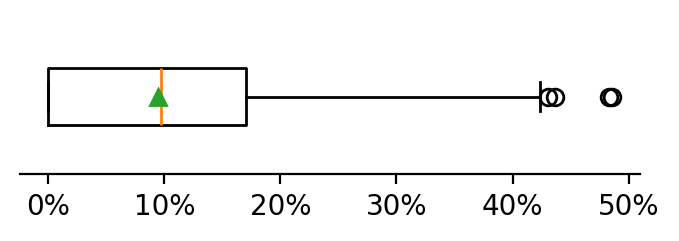

In [103]:
# hide the frame of the plot


fig, ax = plt.subplots(figsize=(4, 1),dpi=200)
ax.boxplot( ratios_qual - ratios_vol, vert=False,  showmeans=True)
# ax.set_xlabel('Quality-based - Volume-based',)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_ylim(0.8, 1.2)
ax.set_yticks([])
ax.set_xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5], ['0%', '10%', '20%', '30%', '40%', '50%'])
plt.show()

In [104]:
(ratios_qual - ratios_vol).mean()

np.float64(0.09424028054146527)

In [105]:
mv_df = converted_data.copy()
mv_df['FFI'] = ffis
mv_df['MFF20'] = mff20s
mv_df['MFF30'] = mff30s
mv_df

,Percentage_Residential,Percentage_Institutional,Percentage_Commercial,Percentage_Industrial,Percentage_Open_Space,Percentage_Freeway,Percentage_Water,Percentage_Unkown,Percent_Impervious,ADD,...,Precipitation_Depth_mm,Drainage_Area_ha,EPA_Rain_Zone,Principal_Landuses,Secondary_land_use,Main_Type_Conveyance,Season,FFI,MFF20,MFF30
0,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,2.365398,...,16.813495,2.185081,2,4,0,4,2,1.683003,3.241834,2.897909
1,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,2.365398,...,16.813495,2.185081,2,4,0,4,3,1.786849,3.892805,3.333333
2,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,2.365398,...,16.813495,2.185081,2,4,0,4,1,1.741322,3.670126,3.333333
3,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,2.365398,...,16.813495,2.185081,2,4,0,4,0,1.645921,2.917702,2.355030
4,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.0,0.50681,2.365398,...,16.813495,2.185081,2,4,0,4,0,1.645921,2.917702,2.355030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9046,0.31,0.0,0.56,0.13,0.0,0.0,0.0,0.0,0.81000,2.365398,...,16.813495,2.953367,0,1,6,0,2,1.758135,3.477390,3.333094
9047,0.31,0.0,0.56,0.13,0.0,0.0,0.0,0.0,0.81000,2.365398,...,16.813495,2.953367,0,1,6,0,0,1.756985,3.442365,3.333333
9048,0.31,0.0,0.56,0.13,0.0,0.0,0.0,0.0,0.81000,2.365398,...,16.813495,2.953367,0,1,6,0,0,1.756985,3.442365,3.333333
9049,0.31,0.0,0.56,0.13,0.0,0.0,0.0,0.0,0.81000,2.365398,...,16.813495,2.953367,0,1,6,0,0,1.756985,3.442365,3.333333


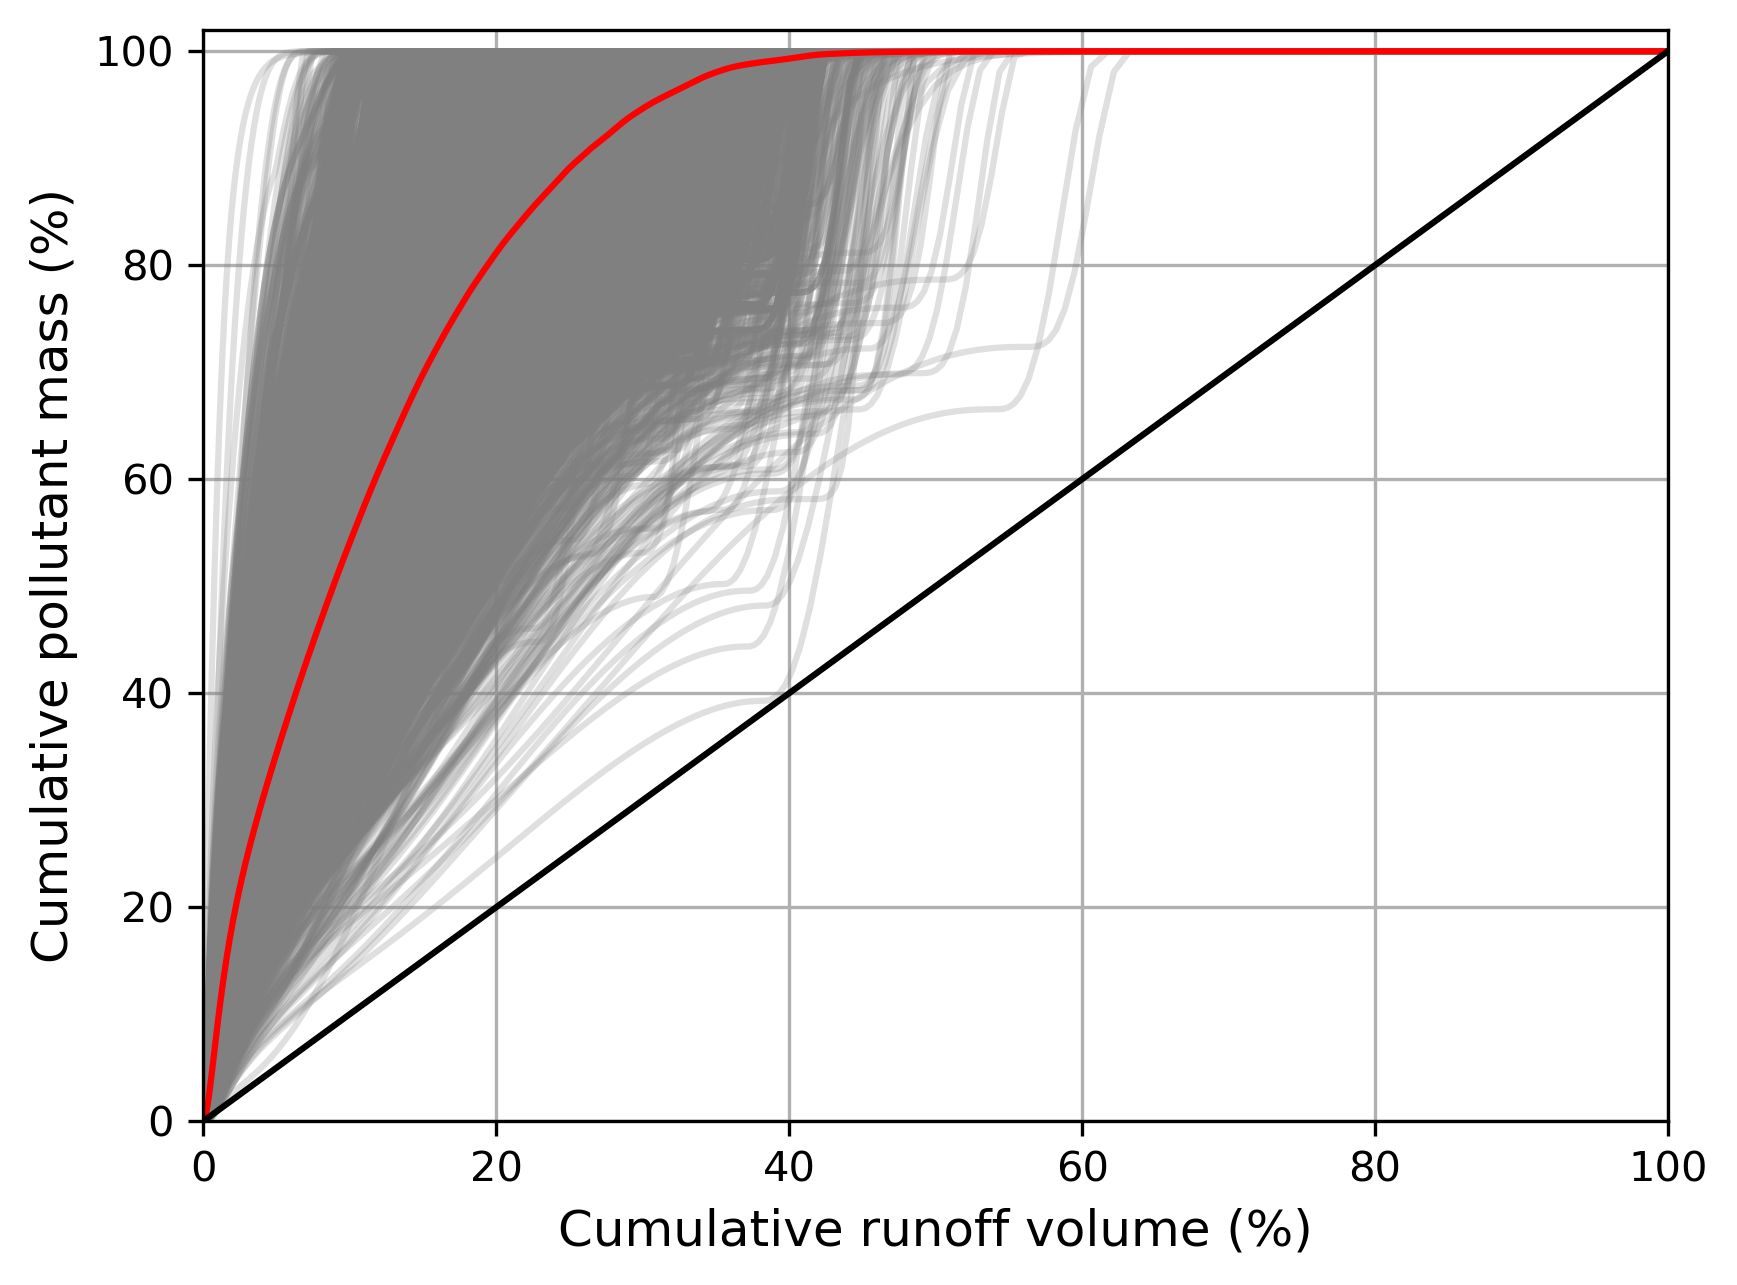

In [106]:

plt.figure(figsize = [16/cm,12/cm], dpi = 300)

plt.plot(xx.T,yy.T, c = 'grey', alpha = 0.25)
x = np.linspace(0,99.9,1000)
y_mean = np.mean(y,axis = 0)

plt.plot(x,y_mean,c = 'r')

f = interp1d(x, y_mean, kind='linear')

plt.xlabel('Cumulative runoff volume (%)', fontsize = 12)
plt.ylabel('Cumulative pollutant mass (%)', fontsize = 12)

plt.plot([0,100],[0,100], c = 'black')
plt.grid()
plt.xlim([0,100])
plt.ylim([0,102])
plt.show()

(array([0., 2., 4., 6.]),
 [Text(1, 0.0, '0'), Text(1, 2.0, '2'), Text(1, 4.0, '4'), Text(1, 6.0, '6')])

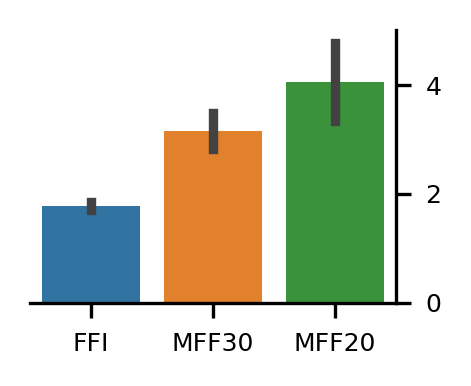

In [107]:
import seaborn as sns
plt.figure(figsize = [4/cm,3/cm], dpi = 300)
sns.barplot(data=mv_df[['FFI','MFF30','MFF20']], errorbar = 'sd')
# move y axis to right

ax = plt.gca()

ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.xticks(fontsize = 6)
plt.yticks(fontsize = 6)


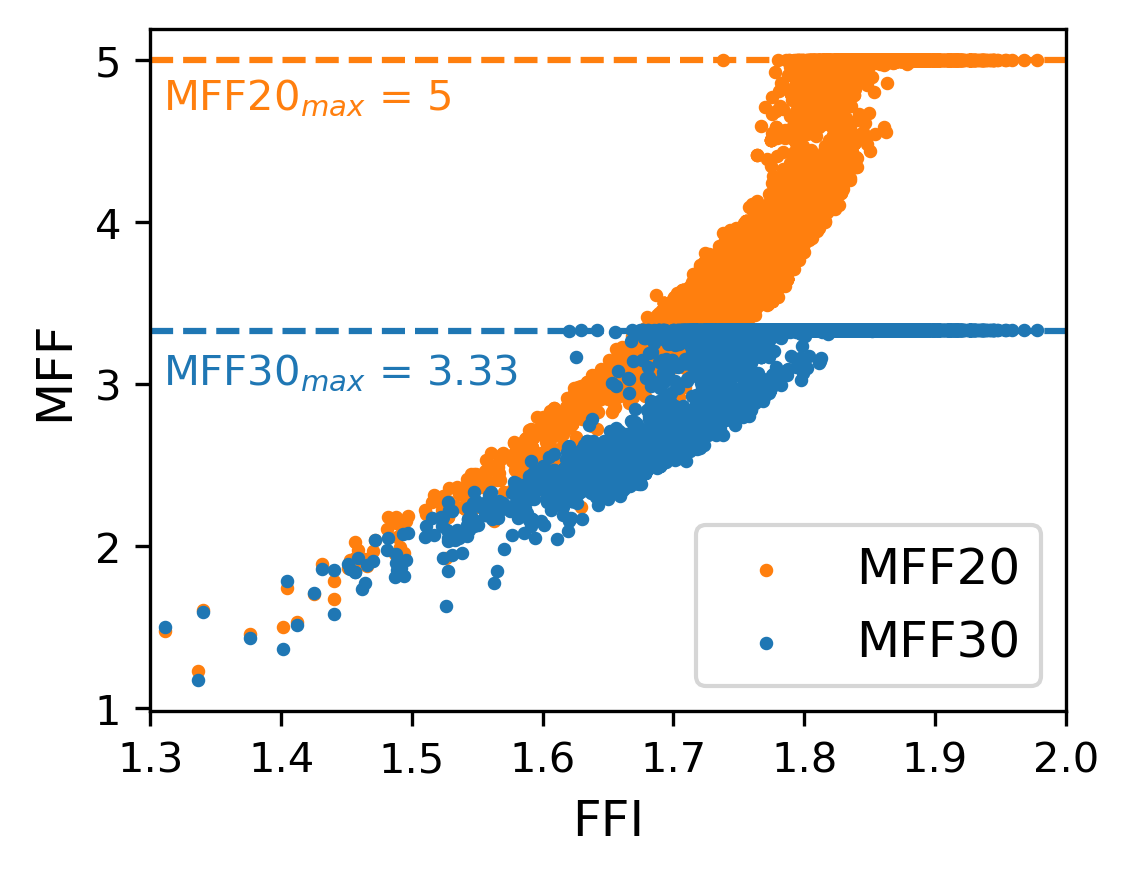

In [108]:
plt.figure(figsize = [10/cm,7.5/cm], dpi = 300)

plt.scatter(mv_df['FFI'], mv_df['MFF20'], color='C1', label = 'MFF20',s=5)
plt.plot((1.3, 2), (5,5), color='C1', linestyle='--')
plt.text(1.31, 4.9, 'MFF20$_{max}$ = 5', color='C1', fontsize=10, va='top', ha='left')

plt.scatter(mv_df['FFI'], mv_df['MFF30'], color='C0', label = 'MFF30',s=5)
plt.plot((1.3, 2), (3.33,3.33), color='C0', linestyle='--')
plt.text(1.31, 3.2, 'MFF30$_{max}$ = 3.33', color='C0', fontsize=10, va='top', ha='left')


plt.xlim(1.3, 2)
plt.legend(fontsize = 12)
plt.xlabel('FFI', fontsize = 12)
plt.ylabel('MFF', fontsize = 12)
plt.show()

### shap to EMC

In [46]:
import shap
from tqdm.notebook import tqdm


In [47]:
class AutogluonWrapper:
    def __init__(self,path, feature_names):
        self.path = path
        self.feature_names = feature_names

    def predict(self, data):

        df = pd.DataFrame(data, columns=self.feature_names)
        if df.isna().values.sum():
            df, obj_dict = dp.data_transform(df)
        
        res = []
        df_batch_size = 10240 * 2
        batch_size = 1024 * 2
        for ii in tqdm(range(df.shape[0]//df_batch_size+1), desc='df batch', leave = False):
            loader = data_loader(df.iloc[(ii)*df_batch_size:(ii+1)*df_batch_size], batch_size = batch_size)

            hidden_size = 256
            input_size = 18
            dropout = 0.1
            net = HybridModel(input_size, hidden_size, n_layers = 2, dropout = 0.1)
            #model_state = load_test[-1]

            with open(path[3], 'rb') as f:
                train_losses, valid_losses,test_losses, best_model_state = pickle.load(f)
                net.load_state_dict(best_model_state)
                net.eval()
                net.to(device)

                
                for i, batch in enumerate(tqdm(loader,desc='loader batch', leave = False)):


                    x, label = [x.to(device) for x in batch]
                
                    with torch.no_grad():
                        runoff, total_runoff, load_record = net(x)
                    
                    pred = (load_record[:,0] - load_record[:,-1])/torch.flatten(total_runoff)
                    res.append(pred.cpu().numpy())
        pred = np.concatenate(res)
        
        return pred

In [48]:
feature_names = converted_data.columns
ag_wrapper = AutogluonWrapper(path[3], feature_names)


In [49]:
X_train_summary = shap.kmeans(converted_data, 50)
X_train_summary

In [61]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    explainer = shap.KernelExplainer(ag_wrapper.predict, X_train_summary)


df batch:   0%|          | 0/1 [00:00<?, ?it/s]

loader batch:   0%|          | 0/1 [00:00<?, ?it/s]

In [62]:
def log_existence(log_file, message):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    message = f"[{timestamp}] {message}\n"
    log_file.write(message)
    log_file.flush()

In [63]:
num_splits = 6

# Shuffle the DataFrame
df_shuffled = converted_data.sample(frac=1, random_state=42) # random_state for reproducibility
# Split the shuffled DataFrame into multiple smaller DataFrames
df_splits = np.array_split(df_shuffled, num_splits)

c:\ProgramData\anaconda3\envs\ag\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [64]:

# Access and display the individual DataFrames
with open('log/progress_3.log', "a") as log_file:
    for i, sub_df in enumerate(df_splits):
        import os

        file_path = f"shap_tss/sub_df_{i}_{len(sub_df)}.npy"
        if os.path.isfile(file_path):
            
            message = f"sub_df_{i}_{len(sub_df)} is existing."
            log_existence(log_file, message)
        else:
            message = f"Cal sub_df_{i}_{len(sub_df)}."
            log_existence(log_file, message)
            
            with warnings.catch_warnings():
                np.save(file_path,np.array([]))
                warnings.simplefilter('ignore')
                random_ffi_1000 = explainer.shap_values(sub_df, nsamples=500)
                np.save(file_path,random_ffi_1000)
                
                message = f"sub_df_{i}_{len(sub_df)} calculated and saved."
                log_existence(log_file, message)


### shap to FFI

In [52]:
class AutogluonWrapper:
    def __init__(self,path, feature_names):
        self.path = path
        self.feature_names = feature_names

    def predict(self, data):
       
        
        print(data.shape)

        df = pd.DataFrame(data, columns=self.feature_names)
        if df.isna().values.sum():
            df, obj_dict = dp.data_transform(df)
        
        ffis = []
        df_batch_size = 10240 * 2
        batch_size = 1024 * 2
        for ii in tqdm(range(df.shape[0]//df_batch_size+1), desc='df batch', leave = False):
            loader = data_loader(df.iloc[(ii)*df_batch_size:(ii+1)*df_batch_size], batch_size = batch_size)

            hidden_size = 256
            input_size = 18
            dropout = 0.1
            net = HybridModel(input_size, hidden_size, n_layers = 2, dropout = 0.1)
            #model_state = load_test[-1]

            with open(path[3], 'rb') as f:
                train_losses, valid_losses,test_losses, best_model_state = pickle.load(f)
                net.load_state_dict(best_model_state)
                net.eval()
                net.to(device)

                
                for i, batch in enumerate(tqdm(loader,desc='loader batch', leave = False)):


                    x, label = [x.to(device) for x in batch]
                
                    with torch.no_grad():
                        runoff, total_runoff, load_record = net(x)
                    dx = 0.1 
                    n = 1000
                    _x = np.linspace(0,99.9,1000)
                    for i in range(runoff.shape[0]):
                        a = np.cumsum(runoff[i,:,0].cpu())
                        a = 100 * a/a[-1]
                        a = np.insert(np.array(a.cpu()),0,0)

                        b = load_record[i,0] - load_record[i,1:]
                        b = 100 * b/b[-1]
                        b = np.insert(np.array(b.cpu()),0,0)

                        f = interp1d(a, b, kind='linear')

                        _y = f(_x)

                        fArea = np.nansum(_y*dx)
                        ffis.append(2*fArea/10000)
                        # plt.plot(a,b, c = 'grey', alpha = 0.25)
        pred = np.array(ffis)
        
        return pred

In [ ]:
feature_names = converted_data.columns
ag_wrapper = AutogluonWrapper(path[3], feature_names)


In [54]:
X_train_summary = shap.kmeans(converted_data, 50)
X_train_summary

In [55]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    explainer = shap.KernelExplainer(ag_wrapper.predict, X_train_summary)


(50, 19)


df batch:   0%|          | 0/1 [00:00<?, ?it/s]

loader batch:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from datetime import datetime
import time

num_splits = 6

# Shuffle the DataFrame
df_shuffled = converted_data.sample(frac=1, random_state=42) # random_state for reproducibility
# Split the shuffled DataFrame into multiple smaller DataFrames
df_splits = np.array_split(df_shuffled, num_splits)

# Access and display the individual DataFrames
with open('log/progress_3.log', "a") as log_file:
    for i, sub_df in enumerate(df_splits):
        import os
        if i < 4:
            continue
        file_path = f"shap_ffi/sub_df_{i}_{len(sub_df)}.npy"
        if os.path.isfile(file_path):
            
            timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            message = f"[{timestamp}] sub_df_{i} is existing.\n"
            log_file.write(message)
            log_file.flush()
        else:
            timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            message = f"[{timestamp}] Cal sub_df_{i}, size = {len(sub_df)}.\n"
            log_file.write(message)
            log_file.flush()
            
            with warnings.catch_warnings():
                np.save(file_path,np.array([]))
                warnings.simplefilter('ignore')
                random_ffi_1000 = explainer.shap_values(sub_df, nsamples=500)
                np.save(file_path,random_ffi_1000)


### Longgang

In [92]:
hidden_size = 256
input_size = 18
dropout = 0.1
net = HybridModel(input_size, hidden_size, n_layers = 2, dropout = 0.1)
#model_state = load_test[-1]

with open(path[1], 'rb') as f:
    train_losses, valid_losses,test_losses, best_model_state = pickle.load(f)
    net.load_state_dict(best_model_state)
    net.eval()
    net.to(device)

In [93]:
robust = pd.read_csv('data/longgang.csv' ,index_col=0)

robust

,Percentage_Residential,Percentage_Institutional,Percentage_Commercial,Percentage_Industrial,Percentage_Open_Space,Percentage_Freeway,Percentage_Water,Percentage_Unkown,Percent_Impervious,ADD,TSS_mgL,Runoff_mm,Precipitation_Depth_mm,Drainage_Area_ha,EPA_Rain_Zone,Principal_Landuses,Secondary_land_use,Main_Type_Conveyance,Season
1,0.410277,0.052964,0.011858,0.113043,0.189723,0.228458,0,0,0.50681,1.945910,2.855730,1.997972,38.6,7.143618,1,10,0,3,1
2,0.264692,0.016659,0.011569,0.069875,0.478945,0.157335,0,0,0.50681,1.945910,3.295273,1.997972,38.6,7.678789,1,10,0,3,1
3,0.330425,0.037804,0.021810,0.083606,0.337332,0.190840,0,0,0.50681,1.945910,3.360446,1.997972,38.6,7.920083,1,10,0,3,1
4,0.210339,0.021390,0.014260,0.190731,0.420232,0.148396,0,0,0.50681,1.945910,2.398722,1.997972,38.6,7.716461,1,10,0,3,1
5,0.177587,0.018075,0.003163,0.165386,0.506552,0.131948,0,0,0.50681,1.945910,4.887153,1.997972,33.4,7.702556,1,10,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,0.100463,0.008333,0.000000,0.160417,0.643287,0.089583,0,0,0.50681,1.609438,3.044543,1.997972,37.8,8.371242,1,10,0,3,1
73,0.145760,0.007759,0.007205,0.078145,0.658784,0.104009,0,0,0.50681,1.609438,2.383106,1.997972,42.0,8.596743,1,10,0,3,1
74,0.340180,0.051773,0.013787,0.063872,0.443163,0.171356,0,0,0.50681,1.609438,3.379109,1.997972,37.8,8.176110,1,10,0,3,1
75,0.194056,0.023261,0.019384,0.189317,0.464786,0.111781,0,0,0.50681,1.609438,3.335933,1.997972,42.0,8.443331,1,10,0,3,1


In [94]:
robust_loader = data_loader(robust, batch_size = robust.shape[0], shuffle=False)
loader = data_loader(converted_data, batch_size = converted_data.shape[0])

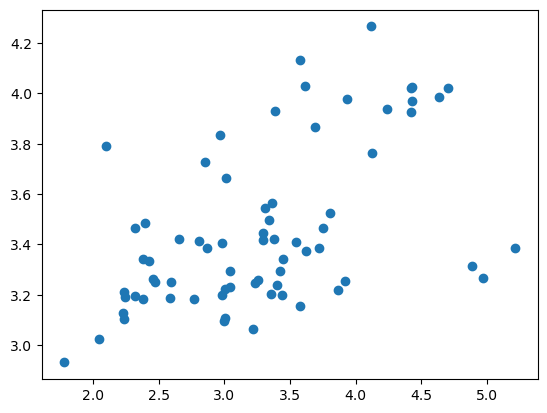

0.210163185139702


In [95]:
for p in path[1:2]:
    with open(p, 'rb') as f:
        train_losses, valid_losses,test_losses, best_model_state = pickle.load(f)
        net.load_state_dict(best_model_state)
        net.eval()
        net.to(device)

    with torch.no_grad():
        data, label = [x.to(device) for x in next(iter(robust_loader))]
        runoff, total_runoff, load_record = net(data)
        total_runoff = torch.where(total_runoff == 0, torch.finfo().tiny, total_runoff)

        pred = (((load_record[:,0] - load_record[:,-1])/torch.flatten(total_runoff)).cpu())
        true = (label[:,0].cpu())
    plt.scatter(true, pred)
    plt.show()
    print(r2_score(true, pred))


train r2 0.210163185139702
train MSE 0.47330248084715953
train MAPE 0.1863076728453279


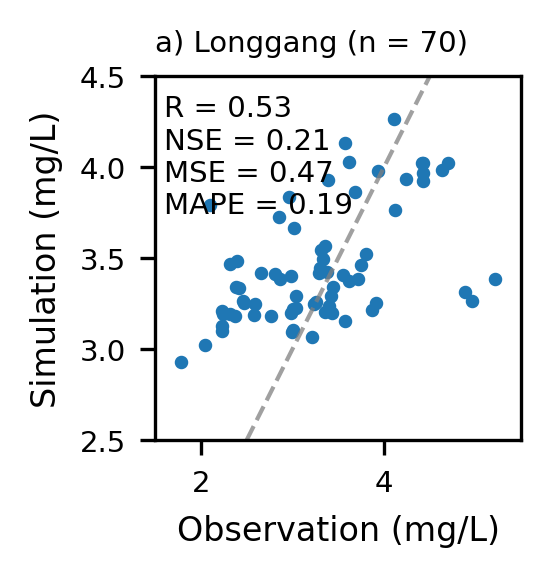

In [96]:

cm=2.54

plt.figure(figsize = [4/cm, 4/cm], dpi = 300)

data, label = [x.to(device) for x in next(iter(robust_loader))]
with torch.no_grad():
  runoff, total_runoff, load_record = net(data)
  total_runoff = torch.where(total_runoff == 0, torch.finfo().tiny, total_runoff)

  pred = (((load_record[:,0] - load_record[:,-1])/torch.flatten(total_runoff)).cpu())
  true = (label[:,0].cpu())

  print('train r2',r2_score(true, pred))
  print('train MSE',mean_squared_error(true, pred) )
  print('train MAPE',mean_absolute_percentage_error(true, pred) )
  # pred = np.expm1(pred)
  # true = np.expm1(true)
  plt.scatter(true, pred, s = 5, label = 'Train set')
  #plt.title('Model '+ str(i) + ' on train set')
  plt.xlabel('Observation (mg/L)',fontsize = 8)
  plt.ylabel('Simulation (mg/L)',fontsize = 8)



  plt.plot([1e0,6],[1e0,6],c = 'gray', ls = '--', alpha = 0.75, lw = 1)
  plt.xlim([1.5,5.5])
  plt.ylim([2.5,4.5])


  # plt.yscale('log')
  # plt.xscale('log')

  # plt.legend(fontsize = 6)
  plt.yticks(fontsize = 7)
  plt.yticks(minor = True, fontsize = 7)

  plt.xticks(fontsize = 7)
  plt.xticks(minor = True, fontsize = 7)
  plt.text(1.6, 4.4, f'R = {np.corrcoef(true, pred)[0,1]:.2f}\nNSE = {r2_score(true, pred):.2f}\nMSE = {mean_squared_error(true, pred):.2f}\nMAPE = {mean_absolute_percentage_error(true, pred):.2f}', fontsize=7, va='top', ha='left')  
  plt.title(f'a) Longgang (n = {len(true)})', fontsize = 7, loc = 'left')
  plt.show()



### Guangming

In [66]:
hidden_size = 256
input_size = 18
dropout = 0.1
net = HybridModel(input_size, hidden_size, n_layers = 2, dropout = 0.1)
#model_state = load_test[-1]

with open(path[2], 'rb') as f:
    train_losses, valid_losses,test_losses, best_model_state = pickle.load(f)
    net.load_state_dict(best_model_state)
    net.eval()
    net.to(device)

In [67]:
robust = pd.read_csv('data/guangming.csv', index_col=0) 
robust

,Percentage_Residential,Percentage_Institutional,Percentage_Commercial,Percentage_Industrial,Percentage_Open_Space,Percentage_Freeway,Percentage_Water,Percentage_Unkown,Percent_Impervious,ADD,TSS_mgL,Runoff_mm,Precipitation_Depth_mm,Drainage_Area_ha,EPA_Rain_Zone,Principal_Landuses,Secondary_land_use,Main_Type_Conveyance,Season
0,0,0,0,0,0.5,0.5,0,0,0.5,17,25.243557,3.15,6.3,0.02400,1,10,0,3,1
1,0,0,0,0,0.5,0.5,0,0,0.5,0,7.556796,9.00,18.0,0.10560,1,10,0,3,1
2,0,0,0,0,0.5,0.5,0,0,0.5,41,27.251157,19.60,39.2,0.10560,1,10,0,3,1
3,0,0,0,0,1.0,0.0,0,0,0.1,17,7.868572,0.67,6.7,0.00991,1,10,0,3,1
4,0,0,0,0,1.0,0.0,0,0,0.1,7,13.878600,3.91,39.1,0.00991,1,10,0,3,1
5,0,0,0,0,1.0,0.0,0,0,0.1,43,5.644152,0.44,4.4,0.00991,1,10,0,3,1
6,0,0,0,0,0.4,0.6,0,0,0.6,0,3.788774,15.36,25.6,0.75000,1,10,0,3,1
7,0,0,0,0,0.4,0.6,0,0,0.6,17,7.647324,4.02,6.7,0.75000,1,10,0,3,1
8,0,0,0,0,0.4,0.6,0,0,0.6,17,5.098296,4.02,6.7,0.75000,1,10,0,3,1
9,0,0,0,0,1.0,0.0,0,0,0.1,32,12.472481,3.22,32.2,4.10000,1,10,0,3,1


In [68]:
robust_loader = data_loader(robust_, batch_size = robust.shape[0], shuffle=False)
loader = data_loader(converted_data, batch_size = converted_data.shape[0])

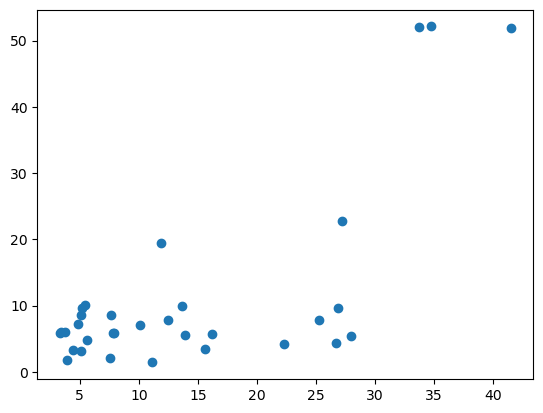

0.08098735155795256


In [69]:
for p in path[3:4]:
    with open(p, 'rb') as f:
        train_losses, valid_losses,test_losses, best_model_state = pickle.load(f)
        net.load_state_dict(best_model_state)
        net.eval()
        net.to(device)

    with torch.no_grad():
        data, label = [x.to(device) for x in next(iter(robust_loader))]
        runoff, total_runoff, load_record = net(data)
        total_runoff = torch.where(total_runoff == 0, torch.finfo().tiny, total_runoff)

        pred = (((load_record[:,0] - load_record[:,-1])/torch.flatten(total_runoff)).cpu())
        true = (label[:,0].cpu())
    plt.scatter(true, pred)
    plt.show()
    print(r2_score(true, pred))


train r2 0.08098735155795256
train MSE 104.81059877910063
train MAPE 0.5453295595983447


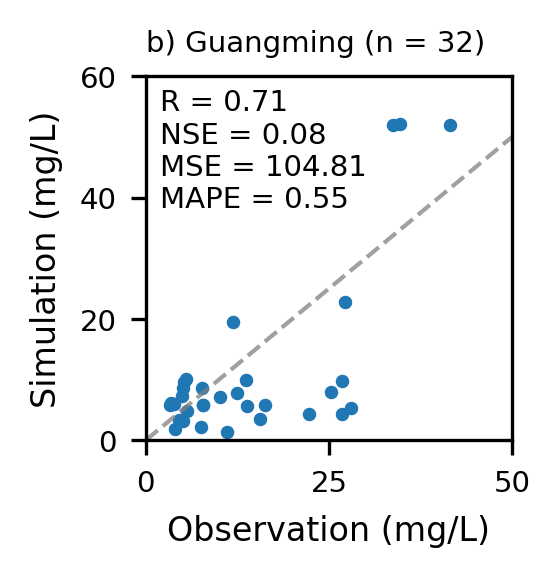

In [60]:

cm=2.54

plt.figure(figsize = [4/cm, 4/cm], dpi = 300)

data, label = [x.to(device) for x in next(iter(robust_loader))]
with torch.no_grad():
  runoff, total_runoff, load_record = net(data)
  total_runoff = torch.where(total_runoff == 0, torch.finfo().tiny, total_runoff)

  pred = (((load_record[:,0] - load_record[:,-1])/torch.flatten(total_runoff)).cpu())
  true = (label[:,0].cpu())

  print('train r2',r2_score(true, pred))
  print('train MSE',mean_squared_error(true, pred) )
  print('train MAPE',mean_absolute_percentage_error(true, pred) )
  # pred = np.expm1(pred)
  # true = np.expm1(true)
  plt.scatter(true, pred, s = 5, label = 'Train set')
  #plt.title('Model '+ str(i) + ' on train set')
  plt.xlabel('Observation (mg/L)',fontsize = 8)
  plt.ylabel('Simulation (mg/L)',fontsize = 8)



  plt.plot([0,60],[0,60],c = 'gray', ls = '--', alpha = 0.75, lw = 1)
  plt.xlim([0,50])
  plt.ylim([0,60])


  # plt.yscale('log')
  # plt.xscale('log')

  # plt.legend(fontsize = 6)
  plt.yticks(fontsize = 7)
  plt.yticks(minor = True, fontsize = 7)

  plt.xticks(fontsize = 7)
  plt.xticks(minor = True, fontsize = 7)
  plt.text(2, 58, f'R = {np.corrcoef(true, pred)[0,1]:.2f}\nNSE = {r2_score(true, pred):.2f}\nMSE = {mean_squared_error(true, pred):.2f}\nMAPE = {mean_absolute_percentage_error(true, pred):.2f}', fontsize=7, va='top', ha='left')  
  plt.title(f'b) Guangming (n = {len(true)})', fontsize = 7, loc = 'left')
  plt.show()



In [75]:
runoff = runoff.cpu().reshape(-1,240)
concentration = -(np.diff(load_record.cpu(), axis = 1)/runoff)

c:\ProgramData\anaconda3\envs\ag\Lib\site-packages\torch\_tensor.py:1102: RuntimeWarning: invalid value encountered in multiply
  return self.reciprocal() * other


In [88]:
all_sheets = pd.read_excel('data/guangming_time_series.xlsx', sheet_name=None)
all_sheets 

{'Sheet1':                   time  TSS_mgL  elapsed_min
 0  2019-04-12 12:23:00       19            0
 1  2019-04-12 12:28:00       21            5
 2  2019-04-12 12:33:00       24           10
 3  2019-04-12 12:38:00       27           15
 4  2019-04-12 12:43:00       25           20
 5  2019-04-12 12:53:00       18           30
 6  2019-04-12 13:03:00       18           40
 7  2019-04-12 13:13:00       30           50
 8  2019-04-12 13:23:00       28           60
 9  2019-04-12 13:53:00       24           90
 10 2019-04-12 14:23:00       27          120
 11 2019-04-12 15:23:00       26          180,
 'Sheet2':                   time  TSS_mgL  elapsed_min
 0  2019-06-11 09:30:00       21            0
 1  2019-06-11 09:35:00       16            5
 2  2019-06-11 09:40:00       19           10
 3  2019-06-11 09:45:00       22           15
 4  2019-06-11 09:50:00       15           20
 5  2019-06-11 09:55:00       19           25
 6  2019-06-11 10:05:00        5           35
 7  2019-06-1

In [89]:
def local_fn(x,y):
    if len(x) < len(y):
        longer = y
        shorter = x
    else:
        longer = x
        shorter = y
    fitness = -np.inf
    match_segment = 0
    for i in range(len(longer)-len(shorter)+1):
        # print(longer[i:i+len(shorter)])
        _df = pd.DataFrame({'x': longer[i:i+len(shorter)] , 'y': shorter})
        if _df.dropna().corr().values[0,1] > fitness:
            fitness = _df.dropna().corr().values[0,1]
            # fitness = r2_score(longer[i:i+len(shorter)], shorter)
            match_segment = _df.dropna().values
            # print(fitness)
    if fitness == -np.inf:
        print('No match segment found.')
        return fitness, None, None
    if len(x) < len(y):
        return fitness, match_segment[:,1], match_segment[:,0]
    else:
        return fitness, match_segment[:,0], match_segment[:,1]
            


No match segment found.


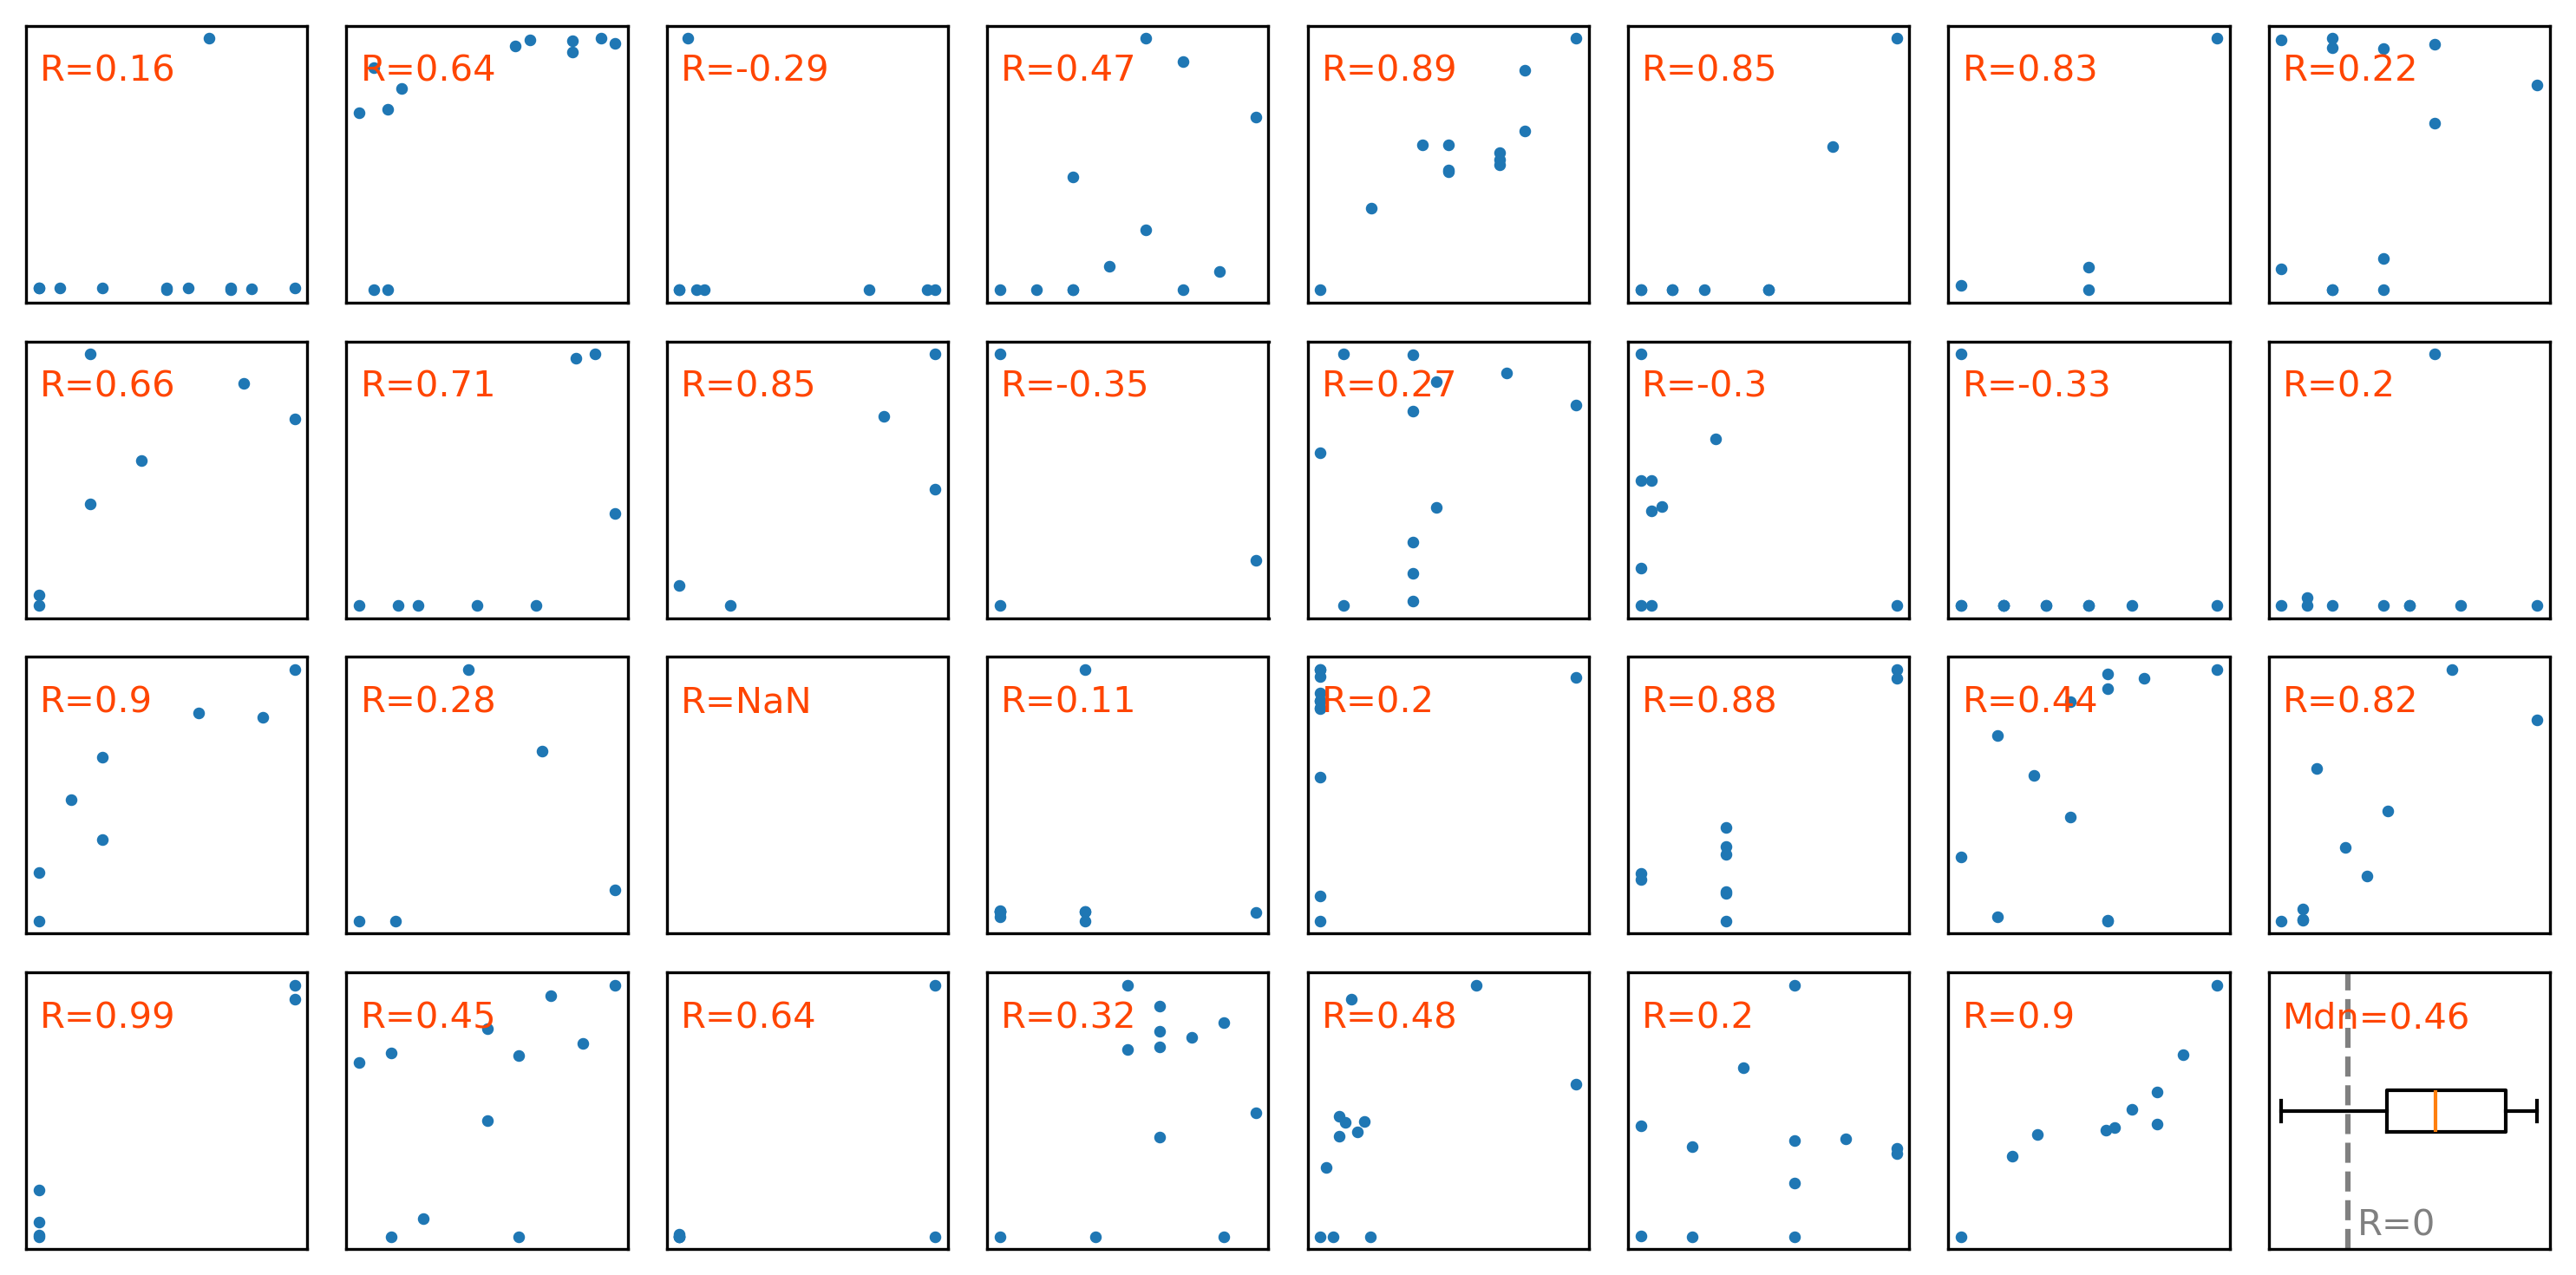

In [90]:
fitnesses = []
fig, ax = plt.subplots(4, 8, figsize = [10, 5], dpi = 300)
for i in range(14):
    df = all_sheets['Sheet'+str(i+1)]
    xx = df.set_index('time')['TSS_mgL'].asfreq('1min').values  
    yy = np.nan_to_num(concentration[i,:].cpu().numpy())
    fitness, seq1, seq2 = local_fn(xx,yy)
    fitnesses.append(fitness)
    ax[i//8,i%8].scatter(seq1,seq2, s=5)
    # no ticks
    ax[i//8,i%8].set_xticks([])
    ax[i//8,i%8].set_yticks([])
    fitness = round(fitness,2) if fitness != -np.inf else 'NaN'
    ax[i//8,i%8].text(0.05, 0.8, f'R={fitness}', transform=ax[i//8,i%8].transAxes, color='orangered')

for i in range(14, 31):
    df = all_sheets['Sheet'+str(i+2)]
    xx = df.set_index('time')['TSS_mgL'].asfreq('1min').values  
    yy = np.nan_to_num(concentration[i,:].cpu().numpy())
    fitness, seq1, seq2 = local_fn(xx,yy)
    fitnesses.append(fitness)
    ax[i//8,i%8].scatter(seq1,seq2, s=5)
    # no ticks
    ax[i//8,i%8].set_xticks([])
    ax[i//8,i%8].set_yticks([])
    fitness = round(fitness,2) if fitness != -np.inf else 'NaN'
    ax[i//8,i%8].text(0.05, 0.8, f'R={fitness}', transform=ax[i//8,i%8].transAxes, color='orangered')

fitnesses = np.array(fitnesses)
fitnesses = fitnesses[~(fitnesses==-np.inf)] 

ax[3,7].boxplot(fitnesses, vert=False)
ax[3,7].axvline(0, color='grey', linestyle='--')
ax[3,7].set_yticks([])
ax[3,7].set_xticks([])
ax[3,7].text(0.05, 0.8, f'Mdn={np.median(fitnesses):.2f}', transform=ax[3,7].transAxes, color='orangered')
ax[3,7].text(0.05, 0.55, f'R=0',color='grey',)

plt.tight_layout()
plt.show()